# Baseline Model for Galaxy Ring Detection


In [4]:
import os
import numpy as np
import pandas as pd
import torch
from astropy.io import fits
from astropy.visualization import make_lupton_rgb
from astropy.stats import SigmaClip
import urllib.request
import matplotlib.pyplot as plt

from astropy.convolution import Gaussian2DKernel, convolve
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.visualization import (AsinhStretch, ImageNormalize,
                                   ZScaleInterval)
from scipy.ndimage import gaussian_filter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from PIL import Image, ImageFile

from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip

In [5]:
#Set path
current_dir = os.getcwd()
path = os.path.join(current_dir)
data_path = os.path.join(path, 'Data')
image_path = os.path.join(path, 'Images')
preprocess_path = os.path.join(path, 'Preprocessed')
os.makedirs(path, exist_ok=True)
os.makedirs(preprocess_path, exist_ok=True)

HOME_PATH = path
DATA_PATH = data_path
IMAGE_PATH = image_path
PREPROCESS_PATH = preprocess_path

print(f"HOME_PATH: {HOME_PATH}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"IMAGE_PATH: {IMAGE_PATH}")
print(f"PREPROCESS_PATH: {PREPROCESS_PATH}")


HOME_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline
DATA_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Data
IMAGE_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images
PREPROCESS_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Preprocessed


In [6]:
#Load table dataset
hdulist = fits.open(f'{DATA_PATH}/dataset.fits')
data = hdulist[1].data
df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == '>i8':
        df[col] = df[col].astype(np.int64)
    elif df[col].dtype == '>f8':
        df[col] = df[col].astype(np.float64)


df['objID'] = df['objID'].astype(str)
print("Shape:", df.shape)
df.describe()


Shape: (8528, 5)


,ra,dec,z,anillos
count,8528.000000,8528.000000,8528.000000,8528.000000
mean,183.268013,25.180086,0.035896,1.767589
std,59.249332,18.394527,0.015032,4.059707
min,0.008759,-11.082615,0.010068,0.000000
25%,153.145473,10.446179,0.024653,0.000000
50%,185.068475,23.905970,0.033006,0.000000
75%,219.528357,39.203309,0.044839,0.000000
max,359.276680,70.133229,0.098892,16.000000


In [7]:
#Preprocesamiento tabular
# Target 3-clases: 0 none, 1 inner, 2 outer, 3 inner+outer
# Regla: 12 (inner+outer) -> outer por ser estructura global más detectable (ajustable)
def to_4class(code):
    if pd.isna(code):
        return np.nan
    code = int(round(code))
    if code == 0: #no ring
        return 0
    if code == 4: #inner ring
        return 1
    if code == 8: #outer ring
        return 2
    if code == 12: #inner + outer ring
        return 3
    # descartamos nuclear(2) y pseudo(16) por decisión de dominio
    return np.nan

#filter out "anillos" == 2 and "anillos" == 16
df = df[(df["anillos"] != 2.0) & (df["anillos"] != 16.0)]
df["ring_class"] = df["anillos"].apply(to_4class)

#filtrar por z
sigma_threshold = 2

mean = df['z'].mean()
std = df['z'].std()

# Define your upper and lower bounds
lower_bound = mean - (sigma_threshold * std)
upper_bound = mean + (sigma_threshold * std)

# Filter the DataFrame
dfGalaxies = df[(df['z'] >= lower_bound) & (df['z'] <= upper_bound)]

In [8]:
dfGalaxies.info()

<class 'pandas.DataFrame'>
Index: 7723 entries, 0 to 8527
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   objID       7723 non-null   str    
 1   ra          7723 non-null   float64
 2   dec         7723 non-null   float64
 3   z           7723 non-null   float64
 4   anillos     7723 non-null   float64
 5   ring_class  7723 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 422.4 KB


In [9]:
from sklearn.utils import resample

#Download and preprocess images
def download_legacy_fits(ra, dec, out_path, size=256, pixscale=0.262, layer="ls-dr9", bands="grz"):
    url = (
        f"https://www.legacysurvey.org/viewer/fits-cutout?"
        f"ra={ra}&dec={dec}&size={size}&layer={layer}&pixscale={pixscale}&bands={bands}"
    )
    print("Downloading from: " + url)
    urllib.request.urlretrieve(url, out_path)

## Class rebalancing strategy: Oversampling with replacement
def rebalance_classes(df, target_col, n_samples_per_class=None):
    if n_samples_per_class is None:
        n_samples_per_class = df[target_col].value_counts().min()
    df_balanced = pd.DataFrame()
    for class_label in df[target_col].unique():
        df_class = df[df[target_col] == class_label]
        df_class_balanced = resample(df_class, replace=True, n_samples=n_samples_per_class, random_state=42)
        df_balanced = pd.concat([df_balanced, df_class_balanced], ignore_index=True)
    return df_balanced

In [10]:
N_SAMPLE = 800

sample_df = rebalance_classes(dfGalaxies, "ring_class", n_samples_per_class=200)

#count per class
print(sample_df["ring_class"].value_counts())

ring_class
0    200
1    200
3    200
2    200
Name: count, dtype: int64


## Download Images

In [11]:
IMAGE_DIR = os.path.join(HOME_PATH, "Images")
os.makedirs(IMAGE_DIR, exist_ok=True)

fits_paths = []
z_values = []
downloaded = 0
for i, row in sample_df.iterrows():
    fname = f"{row['objID']}_{row['ring_class']}.fits"
    fpath = os.path.join(IMAGE_DIR, fname)
    fits_paths.append(fpath)
    z_values.append(row['anillos'])
    if not os.path.exists(fpath):
        try:
            download_legacy_fits(row["ra"], row["dec"], fpath)
            downloaded += 1
        except Exception as e:
            pass

print("Imágenes descargadas en esta corrida:", downloaded)
print("Total de imágenes en carpeta:", len(os.listdir(IMAGE_DIR)))

Imágenes descargadas en esta corrida: 0
Total de imágenes en carpeta: 637


In [12]:
# Función para mapear objID
image_paths = {}
for fn in os.listdir(IMAGE_DIR):
    if fn.lower().endswith(".fits"):
        key = fn.replace(".fits", "")
        print(key)
        #split key by "_" and take the first part as objID
        key = key.split("_")[0]
        image_paths[key] = os.path.join(IMAGE_DIR, fn)

sample_df["img_path"] = sample_df["objID"].astype(str).map(image_paths)
print("Con imagen:", sample_df["img_path"].notna().sum(), " / ", len(dfGalaxies))
sample_df.head()

1237648675606430099_0
1237648703523520869_0
1237648704059670794_0
1237648704590643362_2
1237648720151773317_2
1237648720693756035_1
1237648721225515017_2
1237648721749803336_1
1237648721769332799_1
1237648722826952883_2
1237648722827346065_3
1237649920039125172_1
1237649920579207262_1
1237649961385328865_2
1237650371552346120_1
1237650761850749106_1
1237650796216975382_3
1237651066276872331_3
1237651067884994656_3
1237651190819913868_1
1237651191354622186_3
1237651192436555907_1
1237651212287672671_0
1237651249875845141_1
1237651271350419694_3
1237651271894892577_2
1237651272960835635_1
1237651273515794622_3
1237651298185838753_0
1237651504342892614_3
1237651538710298695_3
1237651735228973059_1
1237651735234543739_2
1237651735767089201_3
1237651735771611332_0
1237651736312676562_1
1237651737378816139_0
1237651737383731214_1
1237651737386352778_0
1237651737390350675_3
1237651753490186430_0
1237651754024108078_0
1237651754543546529_1
1237651755076616319_0
1237651821099810876_1
1237651821

,objID,ra,dec,z,anillos,ring_class,img_path
0,1237651737386352778,222.91171,2.713750,0.033612,0.0,0,c:\Users\Francisco-PC\Documents\Tec de Monterr...
1,1237667324321726469,161.76080,26.542892,0.020994,0.0,0,c:\Users\Francisco-PC\Documents\Tec de Monterr...
2,1237668270824882214,202.66061,18.134611,0.013725,0.0,0,c:\Users\Francisco-PC\Documents\Tec de Monterr...
3,1237667910605799685,216.03493,21.088492,0.047155,0.0,0,c:\Users\Francisco-PC\Documents\Tec de Monterr...
4,1237664870823624896,141.85367,33.698457,0.044866,0.0,0,c:\Users\Francisco-PC\Documents\Tec de Monterr...


In [13]:
#Apply image preprocessing

#Helper methods
def channels_to_rgb(r, g, z):
    """ Convertir los canales en una imágen RGB compuesta.

    Args:
        r (np.ndarray): Canal rojo.
        g (np.ndarray): Canal verde.
        z (np.ndarray): Canal azul.

    Returns:
        np.ndarray: Imagen RGB compuesta.
    """
    # Se utiliza la función make_lupton_rgb debido a que ayuda
    # a manejar el alto rango de imágenes astronómicas controlando
    # el contraste y la saturación, manteniendo el color.
    # Convert input channels to float to avoid UFuncTypeError
    r_float = r.astype(np.float32)
    g_float = g.astype(np.float32)
    z_float = z.astype(np.float32)
    rgb_img = make_lupton_rgb(r_float, g_float, z_float, stretch=0.5, Q=6)
    return rgb_img

#Background Substraction - Reduces noise by substracting the median background from the image
def subtract_sky(data, filter_size = 5, box_size = 50):
    # 1. Define how to identify outliers (stars/galaxy)
    sigma_clip = SigmaClip(sigma=3.0)

    # 2. Define the estimator (Median is robust to bright stars)
    bkg_estimator = MedianBackground()

    # 3. Calculate the background
    # box_size: should be larger than the objects you want to keep!
    # filter_size: smoothes the background map
    bkg = Background2D(data, box_size=(box_size, box_size),
                       filter_size=(filter_size, filter_size),
                       sigma_clip=sigma_clip,
                       bkg_estimator=bkg_estimator)

    # 4. Subtract and return
    return data - bkg.background, bkg.background

def plot_subtraction_check(original, bkg_map, subtracted, band_name="g"):
    # We use ZScaleInterval to automatically find good contrast limits
    norm = ImageNormalize(original, interval=ZScaleInterval(),
                          stretch=AsinhStretch())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Original Image
    im0 = axes[0].imshow(original, origin='lower', norm=norm, cmap='gray')
    axes[0].set_title(f'Original ({band_name})')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # 2. The Estimated Background (The "Sky Model")
    im1 = axes[1].imshow(bkg_map, origin='lower', cmap='viridis')
    axes[1].set_title('Estimated Background')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # 3. The Result (Sky-Subtracted)
    im2 = axes[2].imshow(subtracted, origin='lower', norm=norm, cmap='gray')
    axes[2].set_title('Subtracted Result')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

def apply_background_subtraction(g, r, z):
  clean_g_band, g_bkg_map = subtract_sky(g, filter_size=7, box_size=50)
  clean_r_band, r_bkg_map = subtract_sky(r, filter_size=7, box_size=50)
  clean_z_band, z_bkg_map = subtract_sky(z, filter_size=9, box_size=50)

  return clean_g_band, clean_r_band, clean_z_band

def unsharp_mask(image, sigma=1.0, amount=1.0, threshold=0):
    """
    Applies unsharp masking to a numpy array.
    
    Parameters:
    - image: input numpy array (2D for grayscale, 3D for RGB).
    - sigma: standard deviation for Gaussian blur (controls the width of the edges).
    - amount: multiplier for the sharpening effect (usually 0.5 to 2.0).
    - threshold: minimum brightness change to be sharpened (helps reduce noise).
    """
    # 1. Create the blurred version of the image
    # For RGB images, we don't blur along the color channel axis
    if image.ndim == 3:
        blurred = gaussian_filter(image, sigma=(sigma, sigma, 0))
    else:
        blurred = gaussian_filter(image, sigma=sigma)
    
    # 2. Calculate the mask (Original - Blurred)
    mask = image - blurred
    
    # 3. Apply thresholding if needed to avoid sharpening noise
    if threshold > 0:
        mask[np.abs(mask) < threshold] = 0
    
    # 4. Add the weighted mask back to the original image
    sharpened = image + amount * mask
    
    return blurred, sharpened

#New stars and dust
def calculate_gz_index(g_data, z_data):
    """
    Calculates the g-z Color Index, highlighting younger stars and zones of active stellar formation.
    """
    # 1. Simple Background Subtraction (Median)
    g_data -= np.median(g_data)
    z_data -= np.median(z_data)

    # 2. Calculate the Normalized Difference Index
    # Formula: (g - z) / (g + z)
    # Adding epsilon to denominator to avoid division by zero
    epsilon = 1e-9
    gz_index = g_data / (z_data + epsilon) #(g_data - z_data) / (g_data + z_data + epsilon)

    gz_index = np.clip(gz_index, -0.8, 0.8)

    # 3. Masking low signal-to-noise areas
    # This prevents the 'noise' in the empty background from dominating the index
    mask = (g_data + z_data) < (np.std(g_data) * 1.2)
    gz_index[mask] = np.nan

    return gz_index

#Older stars
def calculate_rz_index(r_data, z_data, r_fwhm=1.2, z_fwhm=1.5):
    """
    Calculates the r-z Color Index, highlighting older stellar populations.
    r_fwhm, z_fwhm: PSF widths (usually in arcseconds or pixels).
    """

    # 1. PSF Matching: Match the sharper r-band to the blurrier z-band
    if z_fwhm > r_fwhm:
        smoothing_sigma = np.sqrt(z_fwhm**2 - r_fwhm**2) / 2.355
        kernel = Gaussian2DKernel(x_stddev=smoothing_sigma)
        r_data = convolve(r_data, kernel)

    # 2. Basic Background Subtraction
    r_data -= np.nanmedian(r_data)
    z_data -= np.nanmedian(z_data)

    # 3. Normalized Difference Index: (r - z) / (r + z)
    epsilon = 1e-10
    rz_index = (r_data - z_data) / (r_data + z_data + epsilon)

    # 4. Clipping and Masking
    # r-z typically has a tighter range than g-z, so we clip slightly differently
    rz_index = np.clip(rz_index, -0.6, 0.6)

    combined_signal = r_data + z_data
    mask = combined_signal < (1.2 * np.nanstd(combined_signal))
    rz_index[mask] = np.nan

    return rz_index


def calculate_gr_index(g_data, r_data, r_fwhm=1.5, g_fwhm=1.3):
    """
    Calculates the g-r Color Index, highlighting the contrast between
    young blue stars and the intermediate-age stellar disk.
    """
    # 1. PSF Matching: Match the sharper band (usually g) to the blurrier one (usually r)
    if r_fwhm > g_fwhm:
        smoothing_sigma = np.sqrt(r_fwhm**2 - g_fwhm**2) / 2.355
        kernel = Gaussian2DKernel(x_stddev=smoothing_sigma)
        g_data = convolve(g_data, kernel)
    elif g_fwhm > r_fwhm:
        smoothing_sigma = np.sqrt(g_fwhm**2 - r_fwhm**2) / 2.355
        kernel = Gaussian2DKernel(x_stddev=smoothing_sigma)
        r_data = convolve(r_data, kernel)

    # 2. Background Normalization
    g_data -= np.nanmedian(g_data)
    r_data -= np.nanmedian(r_data)

    # 3. G-R Index Calculation: (g - r) / (g + r)
    epsilon = 1e-10
    gr_index = (g_data - r_data) / (g_data + r_data + epsilon)

    # 4. Clipping and Masking
    # g-r has a very specific range; values > 0.5 are quite "red", < 0.2 are "blue"
    gr_index = np.clip(gr_index, -0.4, 0.4)

    combined_signal = g_data + r_data
    mask = combined_signal < (1.2 * np.nanstd(combined_signal))
    gr_index[mask] = np.nan

    return gr_index

#Apply asinh normalization to each band; then stack in a rgb image
def asinh_normalize(idx, softening=0.1):
    """
    Applies Asinh stretching and scales to [0, 1].
    softening: Lower values make the stretch more aggressive (brighter arms).
    """
    # 1. Handle NaNs by setting to a neutral baseline
    idx_clean = np.nan_to_num(idx, nan=np.nanmedian(idx))

    # 2. Shift to positive range if necessary
    # (Indices can be negative, so we shift based on the minimum)
    shifted_idx = idx_clean - np.nanmin(idx_clean)

    # 3. Apply Asinh: arcsinh(x / softening)
    stretched = np.arcsinh(shifted_idx / softening)

    # 4. Final Min-Max Scale to [0, 1] for RGB compatibility
    s_min, s_max = stretched.min(), stretched.max()
    return (stretched - s_min) / (s_max - s_min)

def create_stretched_index_rgb(gz_index, rz_index, gr_index, softening=0.05):
    """
    Combines indices into an RGB image with Asinh stretching.
    """
    rgb_image = np.zeros((*gz_index.shape, 3))

    # Apply stretch to each channel
    rgb_image[..., 0] = asinh_normalize(rz_index, softening) # Red
    rgb_image[..., 1] = asinh_normalize(gz_index, softening) # Blue
    rgb_image[..., 2] = asinh_normalize(gr_index, softening) # Green

    # Mask the background back to black using the original NaNs from gz_index
    mask = np.isnan(gz_index)
    rgb_image[mask] = 0

    return rgb_image

## Preprocessing

In [14]:
#save all results in an array for visualization

results = []
errors = []

for row in sample_df.itertuples():
  objID = row.objID
  img_path = row.img_path
  g_band = []
  r_band = []
  z_band = []
  print(f"Processing {objID} at {img_path}")
  if (img_path is not None and img_path is not np.nan and os.path.exists(img_path)):
    with fits.open(img_path) as hdu:
      try:
        #get label from filename (split by "_")
        label = os.path.basename(img_path).split('_')[1]

        data = hdu[0].data
        g_band = data[0]
        r_band = data[1]
        z_band = data[2]

        blurred_g, enhanced_g = unsharp_mask(g_band, sigma=5.5, amount=3.5)
        blurred_r, enhanced_r = unsharp_mask(r_band, sigma=5.5, amount=3.5)
        blurred_z, enhanced_z = unsharp_mask(z_band, sigma=7.5, amount=3.5)

        #color indices
        gz_index_map = calculate_gz_index(enhanced_g, enhanced_z)
        rz_index_map = calculate_rz_index(enhanced_r, enhanced_z)
        gr_index_map = calculate_gr_index(enhanced_g, enhanced_r)

        rgb_final = create_stretched_index_rgb(gz_index_map, rz_index_map, gr_index_map)

        #convert to grayscale
        final_image = np.mean(rgb_final, axis=2)

        #save as fits at PREPROCESS_PATH
        out_fits_path = os.path.join(preprocess_path, f"{objID}_{label}")
        hdu_out = fits.PrimaryHDU(final_image)
        hdu_out.writeto(out_fits_path, overwrite=True)
      except:
        print(f"Error processing {objID}")
        errors.append(objID)
        pass

print("Preprocessing completed. Errors with the following objIDs:", errors)


Processing 1237651737386352778 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237651737386352778_0.fits
Processing 1237667324321726469 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237667324321726469_0.fits
Processing 1237668270824882214 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237668270824882214_0.fits
Processing 1237667910605799685 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237667910605799685_0.fits
Processing 1237664870823624896 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237664870823624896_0.fits
Processing 1237662263250190437 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237662263250190437_0.fits
Processing 1237668586505306233 at c:\Users\Fra

Processing 1237664291534536771 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237664291534536771_0.fits
Processing 1237655124477935785 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237655124477935785_0.fits
Processing 1237663786879615313 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237663786879615313_0.fits
Processing 1237668349207445599 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237668349207445599_0.fits
Processing 1237651212287672671 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237651212287672671_0.fits
Processing 1237665226771333208 at c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Baseline\Images\1237665226771333208_0.fits
Processing 1237660024523915418 at c:\Users\Fra

## Pre-trained Convolutional Neural Network (ResNet 18) 

In [15]:
[f for f in os.listdir(PREPROCESS_PATH)]

['1237648675606430099_0.fits',
 '1237648703523520869_0.fits',
 '1237648704059670794_0.fits',
 '1237648704590643362_2.fits',
 '1237648720151773317_2.fits',
 '1237648720693756035_1.fits',
 '1237648721225515017_2.fits',
 '1237648721749803336_1.fits',
 '1237648721769332799_1.fits',
 '1237648722826952883_2.fits',
 '1237648722827346065_3.fits',
 '1237649920039125172_1.fits',
 '1237649920579207262_1.fits',
 '1237649961385328865_2.fits',
 '1237650371552346120_1.fits',
 '1237650761850749106_1.fits',
 '1237650796216975382_3.fits',
 '1237651066276872331_3.fits',
 '1237651067884994656_3.fits',
 '1237651190819913868_1.fits',
 '1237651191354622186_3.fits',
 '1237651192436555907_1.fits',
 '1237651212287672671_0.fits',
 '1237651249875845141_1.fits',
 '1237651271350419694_3.fits',
 '1237651271894892577_2.fits',
 '1237651272960835635_1.fits',
 '1237651273515794622_3.fits',
 '1237651298185838753_0.fits',
 '1237651504342892614_3.fits',
 '1237651538710298695_3.fits',
 '1237651735228973059_1.fits',
 '123765

In [33]:
from torch.utils.data import Dataset, DataLoader
from astropy.io import fits
import numpy as np
import os

class FitsDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        
        # Filter for .fits files and sort to maintain consistency
        self.filenames = sorted([f for f in os.listdir(directory) if f.endswith('.fits')])
        
        # Extract labels from [objID]_[label].fits
        self.labels = [f.split('_')[1].replace('.fits', '') for f in self.filenames]
        
        # Map unique string labels to integers
        self.unique_labels = sorted(list(set(self.labels)))
        self.label_to_idx = {label: i for i, label in enumerate(self.unique_labels)}

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        file_path = os.path.join(self.directory, self.filenames[idx])

        # Load FITS file with 3 bands (g, r, z) or single channel
        with fits.open(file_path) as hdul:
            data = hdul[0].data.astype(np.float32)
            # Ensure data is (C, H, W)
            if data.ndim == 2:
                data = data[np.newaxis, ...]  # [1, H, W]
            # If single channel, repeat to 3 channels
            if data.shape[0] == 1:
                data = np.repeat(data, 3, axis=0)  # [3, H, W]

        # Convert numpy array to tensor first
        image = torch.from_numpy(data)

        # Get label and convert to tensor
        label_idx = self.label_to_idx[self.labels[idx]]
        label_tensor = torch.tensor(label_idx, dtype=torch.long)

        # Apply transform if provided (now working on tensor, not numpy)
        if self.transform:
            image = self.transform(image)

        return image, label_tensor

In [34]:
from torchvision import models
from torchvision import transforms

#Resize preprocessed images to 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [35]:
#Load Dataset
fits_data = FitsDataset(directory=PREPROCESS_PATH, transform=transform)

# Create the DataLoader
dataloader = DataLoader(
    fits_data, 
    batch_size=64, 
    shuffle=True
)

# Iterate through batches
for batch_idx, (images, labels) in enumerate(dataloader):
    print(f"Batch {batch_idx} | Shape: {images.shape} | Labels: {labels}")

Batch 0 | Shape: torch.Size([64, 3, 224, 224]) | Labels: tensor([2, 1, 1, 0, 0, 1, 3, 3, 0, 3, 1, 0, 2, 1, 0, 0, 3, 3, 3, 2, 0, 1, 1, 0,
        0, 2, 1, 1, 2, 2, 3, 2, 1, 0, 3, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 3,
        3, 2, 3, 1, 0, 3, 2, 0, 3, 1, 2, 1, 0, 0, 0, 2])
Batch 1 | Shape: torch.Size([64, 3, 224, 224]) | Labels: tensor([1, 0, 0, 3, 2, 2, 1, 1, 3, 1, 3, 3, 3, 3, 0, 2, 2, 3, 1, 2, 0, 3, 2, 1,
        2, 0, 1, 0, 1, 0, 0, 0, 3, 0, 3, 3, 3, 0, 3, 0, 0, 3, 0, 0, 1, 0, 2, 3,
        3, 0, 3, 1, 0, 0, 2, 1, 0, 1, 1, 0, 0, 1, 3, 0])
Batch 2 | Shape: torch.Size([64, 3, 224, 224]) | Labels: tensor([0, 1, 1, 3, 0, 0, 1, 1, 3, 0, 0, 0, 2, 1, 3, 1, 2, 1, 1, 3, 0, 3, 3, 1,
        0, 0, 1, 0, 3, 0, 0, 2, 3, 3, 1, 1, 2, 1, 1, 0, 2, 2, 2, 0, 0, 0, 3, 2,
        1, 0, 3, 2, 3, 2, 3, 3, 1, 3, 1, 0, 0, 2, 3, 0])
Batch 3 | Shape: torch.Size([64, 3, 224, 224]) | Labels: tensor([2, 0, 1, 0, 1, 3, 0, 1, 1, 2, 1, 2, 1, 3, 3, 0, 2, 2, 2, 1, 0, 1, 1, 1,
        3, 1, 1, 1, 3, 3, 1, 0, 2, 3, 1, 

In [36]:
from torch.utils.data import random_split
# Test - Val split
# Define lengths (e.g., 80% train, 10% val, 10% test)
train_size = int(0.7 * len(fits_data))
val_size = int(0.2 * len(fits_data))
test_size = len(fits_data) - train_size - val_size

# 3. Perform the split
train_ds, val_ds, test_ds = random_split(
    fits_data, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) # For reproducibility
)

# 4. Create DataLoaders as usual
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

In [37]:
#Set up GPU if available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

cuda


In [38]:
#Training Loop
import torch.nn.functional as F

def accuracy(model, loader):
    num_correct = 0
    num_total = 0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for (xi, yi) in loader:
            xi = xi.to(device=device, dtype = torch.float32)
            yi = yi.to(device=device, dtype = torch.long)
            scores = model(xi) # mb_size, 10
            _, pred = scores.max(dim=1) #pred shape (mb_size )
            num_correct += (pred == yi).sum() # pred shape (mb_size), yi shape (mb_size, 1)
            num_total += pred.size(0)
        return float(num_correct)/num_total

def train(model, loader, optimiser, epochs=5):
    model = model.to(device=device)
    train_acc_history = []
    train_cost_history = []
    val_acc_history = []
    val_cost_history = []
    for epoch in range(epochs):
        model.train()
        epoch_cost = 0.0
        epoch_correct = 0
        epoch_total = 0
        for (xi, yi) in loader:
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            cost = F.cross_entropy(input= scores, target=yi)
            optimiser.zero_grad()
            cost.backward()
            optimiser.step()
            epoch_cost += cost.item() * xi.size(0)
            _, pred = scores.max(dim=1)
            epoch_correct += (pred == yi).sum().item()
            epoch_total += pred.size(0)
        train_acc = epoch_correct / epoch_total if epoch_total > 0 else 0
        train_cost = epoch_cost / epoch_total if epoch_total > 0 else 0
        train_acc_history.append(train_acc)
        train_cost_history.append(train_cost)

        # Validation
        model.eval()
        val_cost = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for (xi, yi) in val_loader:
                xi = xi.to(device=device, dtype=torch.float32)
                yi = yi.to(device=device, dtype=torch.long)
                scores = model(xi)
                cost = F.cross_entropy(input=scores, target=yi)
                val_cost += cost.item() * xi.size(0)
                _, pred = scores.max(dim=1)
                val_correct += (pred == yi).sum().item()
                val_total += pred.size(0)
        val_acc = val_correct / val_total if val_total > 0 else 0
        val_cost = val_cost / val_total if val_total > 0 else 0
        val_acc_history.append(val_acc)
        val_cost_history.append(val_cost)

        print(f'Epoch: {epoch}, train_cost: {train_cost:.4f}, train_acc: {train_acc:.4f}, val_cost: {val_cost:.4f}, val_acc: {val_acc:.4f}')

    history = {
        'train_acc': train_acc_history,
        'train_cost': train_cost_history,
        'val_acc': val_acc_history,
        'val_cost': val_cost_history
    }
    return history

In [39]:
lr = 5e-4

##Load pretrained ResNet18 model
model = models.resnet18(weights='IMAGENET1K_V1')

#Modify the last fully connected layer to output 4 classes
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 4)
model_resnet18 = model

#unfreeze all layers for fine-tuning
for param in model_resnet18.parameters():
    param.requires_grad = True

optimiser = torch.optim.Adam(model_resnet18.parameters(), lr=lr, betas=(0.9, 0.999))

print(model_resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [40]:
epochs = 20
history = train(model_resnet18, train_loader, optimiser, epochs)
history

Epoch: 0, train_cost: 1.5195, train_acc: 0.3303, val_cost: 3.9371, val_acc: 0.2283
Epoch: 1, train_cost: 1.0915, train_acc: 0.5416, val_cost: 3.5094, val_acc: 0.2126
Epoch: 2, train_cost: 0.7310, train_acc: 0.6921, val_cost: 1.6813, val_acc: 0.4016
Epoch: 3, train_cost: 0.3765, train_acc: 0.8629, val_cost: 1.8939, val_acc: 0.3465
Epoch: 4, train_cost: 0.2138, train_acc: 0.9348, val_cost: 2.3047, val_acc: 0.3071
Epoch: 5, train_cost: 0.1478, train_acc: 0.9573, val_cost: 2.5009, val_acc: 0.3622
Epoch: 6, train_cost: 0.1380, train_acc: 0.9573, val_cost: 3.5504, val_acc: 0.3543
Epoch: 7, train_cost: 0.2215, train_acc: 0.9326, val_cost: 2.5387, val_acc: 0.3780
Epoch: 8, train_cost: 0.2057, train_acc: 0.9258, val_cost: 2.6884, val_acc: 0.3150
Epoch: 9, train_cost: 0.1893, train_acc: 0.9348, val_cost: 3.9979, val_acc: 0.3228
Epoch: 10, train_cost: 0.1768, train_acc: 0.9506, val_cost: 2.7657, val_acc: 0.3858
Epoch: 11, train_cost: 0.1409, train_acc: 0.9640, val_cost: 3.0813, val_acc: 0.3701
Ep

{'train_acc': [0.3303370786516854,
  0.5415730337078651,
  0.6921348314606741,
  0.8629213483146068,
  0.9348314606741573,
  0.9573033707865168,
  0.9573033707865168,
  0.9325842696629213,
  0.9258426966292135,
  0.9348314606741573,
  0.950561797752809,
  0.9640449438202248,
  0.9707865168539326,
  0.9685393258426966,
  0.9820224719101124,
  0.9977528089887641,
  0.9910112359550561,
  0.9932584269662922,
  0.9977528089887641,
  0.9887640449438202],
 'train_cost': [1.519459367602059,
  1.0914946775757866,
  0.7309565378039071,
  0.3764820916599102,
  0.21379350875870565,
  0.1477746427394031,
  0.13795187567057235,
  0.2215166833963287,
  0.20568713117181586,
  0.18930419328507414,
  0.17680830781379442,
  0.14088584285103872,
  0.10081164026528262,
  0.08165618372097444,
  0.05090510054920497,
  0.026795837617992015,
  0.0403271690345882,
  0.02457099136676681,
  0.019043016493885536,
  0.030469375363226688],
 'val_acc': [0.2283464566929134,
  0.2125984251968504,
  0.4015748031496063,


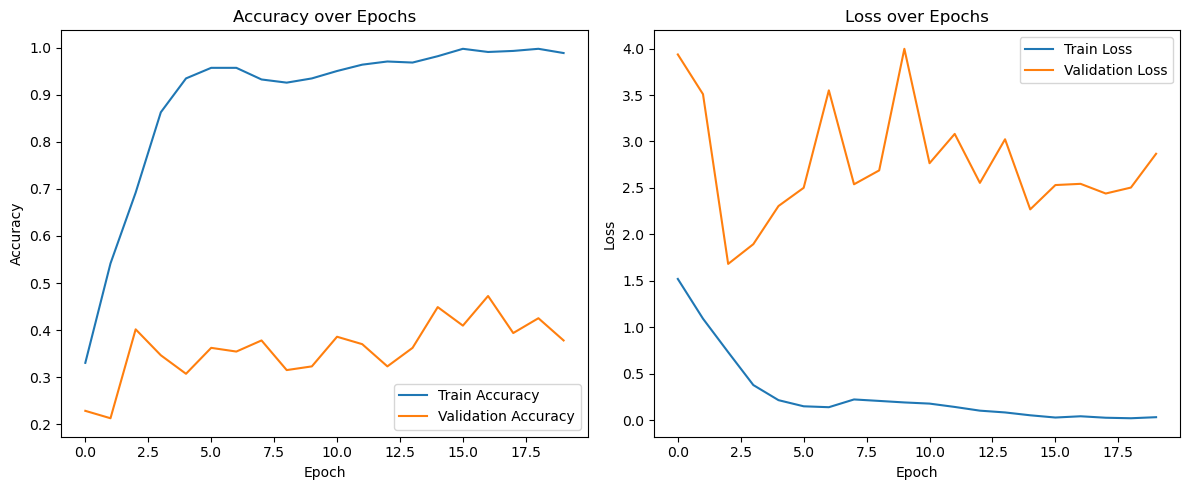

In [41]:
#Visualize history using matplotlib
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['train_cost'], label='Train Loss')
plt.plot(history['val_cost'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()